## Overview
In this section, we will evaluate the effectiveness of XGBoost as a model for predicting delays in the TTC.

### Task
As a preliminary test, we will first focus on seeing if XGBoost could correctly predict the occurances of the delays, making this a **Classification Task**

### Motivation
The motivation behind this model is that the recorded subway delay data is largely tabular. And although the delay data would theoretically be sequentially dependent, the TTC only seems to record the cause of delays, so any subsequent delays caused by the delay of one is not recorded. This could significantly lessen the temporal dependency of our data.

### Initial Challenges
The largest initial challenge is that the TTC dataset only contains the entries which caused a delay, so the positive (1) set, without any of the normal operations. To the negative class, we will use synthetic data created in the following manner: 
* All stations on all lines will have trains from 5:30am to 2am (this is approximation, in reality most stations have trains between 5:30am -> 1:30am to 6:00am -> 2am). 
* As per the TTC website. During rush hours 6am to 9am and 3pm to 7pm, there is a train every 3 minutes for Lines 1 and 2. Other times will have a train running every 5 minutes. For Line 4, there is always a train every 5 minutes.
* However, also note that this will mean that there would be an enormous amount of data in our dataset. To slightly combat this

In [2]:
import pandas as pd
from datetime import datetime, timedelta

In [2]:
terminal_stations = {
    'LINE 1' : ['VAUGHAN METROPOLITAN CENTRE STATION', 'FINCH STATION'],
    'LINE 2' : ['KENNEDY STATION', 'KIPLING STATION'],
    'LINE 4' : ['SHEPPARD-YONGE STATION', 'DON MILLS STATION'],
}

def is_terminal_station(line, station_name):
    if line == 'LINE 1 and LINE 2':
        line = 'LINE 1'
    if station_name in terminal_stations[line]: 
        return True
    return False

In [11]:
df = pd.read_csv('../data/cleaned_data_with_bounds.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df['Delayed'] = 1  # Mark original records as delayed
# Drop the Vehicle ID column
# original_df = original_df.drop(columns=['Vehicle'])
start_date = datetime(2022, 1, 1)
end_date = datetime(2024, 12, 31)
original_index = 0

# Make original df the original data frame starting datetime = 2022-01-01 00:00:00
original_df = df[(df['Datetime'] >= start_date) & (df['Datetime'] < end_date)].copy()

original_df.head()

,Datetime,Day,Station Name,Line Number,Min Delay,Min Gap,Bound,Vehicle,Cause for Delay,Is Rush Hour,Is Terminal Station,Delayed
47020,2022-01-01 07:43:00,Saturday,WILSON STATION,LINE 1,10,0,S,5896,ATC Operator Related,False,False,1
47021,2022-01-01 08:12:00,Saturday,FINCH STATION,LINE 1,6,12,S,0,No Operator Immediately Available,False,True,1
47022,2022-01-01 08:28:00,Saturday,GREENWOOD STATION,LINE 2,5,10,E,5091,Transportation Department - Other,False,False,1
47023,2022-01-01 09:45:00,Saturday,KENNEDY STATION,LINE 2,5,10,W,5153,Transportation Department - Other,False,True,1
47024,2022-01-01 09:51:00,Saturday,FINCH STATION,LINE 1,6,12,S,0,No Operator Immediately Available,False,True,1


In [ ]:
# map ridership


In [5]:
# Define date range: January 1, 2022 to December 31, 2024
start_date = datetime(2022, 1, 1)
end_date = datetime(2024, 12, 31)
original_index = 0

# Example list of station names (replace with your actual station list)
stations = {}

for i in [1, 2, 4]:
    with open(f'../../data/delays/subway/stations_on_lines/line{i}.txt', 'r') as f:
        station = f.read().splitlines()[1:]
    for s in station:
        if s in stations:
            stations[s + " STATION"]  += [f'LINE {i}']
        else:
            stations[s+ " STATION"] = [f'LINE {i}']

print(stations)

# Define lines of interest; adjust if you have more lines
lines = ["LINE 1", "LINE 2", "LINE 1 and LINE 2"]

# Function to determine if a given time is in rush hour for Lines 1 and 2
def is_rush_hour(current_time, line):
    # If Saturday or Sunday, rush hour is not applicable
    if current_time.weekday() >= 5:
        return False

    # Only applies for LINE 1 and LINE 2
    if line in ["LINE 1", "LINE 2"]:
        minutes = current_time.hour * 60 + current_time.minute
        # Morning rush: 6:00-9:00 (360 to 540 minutes)
        # Afternoon rush: 3:00-7:00 (900 to 1140 minutes)
        return (360 <= minutes < 540) or (900 <= minutes < 1140)
    return False

# Container for synthetic records
synthetic_records = []

# Loop through each day in the date range
current_date = start_date
while current_date <= end_date:
    for station in stations:
        for line in stations[station]:
            # Define the service period for the current day:
            # Service starts at 5:30 am on the current day...
            day_start = current_date.replace(hour=6, minute=0, second=0, microsecond=0)
            # ...and ends at 2:00 am the next day.
            day_end = (current_date + timedelta(days=1)).replace(hour=1, minute=0, second=0, microsecond=0)

            delays = original_df[
                (original_df['Datetime'] >= day_start) &
                (original_df['Datetime'] < day_end) &
                (original_df['Station Name'] == station) &
                (original_df['Line Number'] == line)
            ]

            
            current_time = day_start
            while current_time <= day_end:
                
                # Determine the frequency (in minutes) based on the line and time of day
                # Sampling every 2 trains for all time periods
                if line in ["LINE 1", "LINE 2", "LINE 1 and LINE 2"]:
                    freq = 6 if is_rush_hour(current_time, line) else 10
                else:
                    freq = 10

                # Check if there are any delays for the current time
                if not delays[(delays['Datetime'] >= current_time) & (delays['Datetime'] < current_time + timedelta(minutes=15))].empty:
                    # If there's a delay, skip to the next time slot
                    current_time += timedelta(minutes=freq)
                    continue

                if line == "LINE 1":
                    bounds = ['N', 'S']
                else:
                    bounds = ['E', 'W']
                
                for bound in bounds:
                    # Create the synthetic record
                    record = {
                        "Datetime": current_time,
                        "Day": current_time.strftime("%A"),
                        "Station Name": station,
                        "Line Number": line,
                        "Min Delay": 0,
                        "Min Gap": 0,
                        "Bound": bound,
                        "Cause for Delay": "No Delay",
                        "Is Rush Hour": is_rush_hour(current_time, line),
                        "Is Terminal Station": is_terminal_station(line, station),
                        "Delayed": 0,  # No delay for synthetic records
                    }
                    synthetic_records.append(record)
                current_time += timedelta(minutes=freq)
    current_date += timedelta(days=1)

# Create a DataFrame with the synthetic schedule records
synthetic_df = pd.DataFrame(synthetic_records)

# Optionally, add a label column to indicate that these records have no delays (e.g., 0)
synthetic_df["Delayed"] = 0

# Preview the generated data and record count
print(synthetic_df.head())
print("Total synthetic records generated:", len(synthetic_df))

combined_df = pd.concat([original_df, synthetic_df], ignore_index=True)

{'FINCH STATION': ['LINE 1'], 'NORTH YORK CENTRE STATION': ['LINE 1'], 'SHEPPARD-YONGE STATION': ['LINE 4'], 'YORK MILLS STATION': ['LINE 1'], 'LAWRENCE STATION': ['LINE 1'], 'EGLINTON STATION': ['LINE 1'], 'DAVISVILLE STATION': ['LINE 1'], 'ST CLAIR STATION': ['LINE 1'], 'SUMMERHILL STATION': ['LINE 1'], 'ROSEDALE STATION': ['LINE 1'], 'BLOOR-YONGE STATION': ['LINE 2'], 'WELLESLEY STATION': ['LINE 1'], 'COLLEGE STATION': ['LINE 1'], 'DUNDAS STATION': ['LINE 1'], 'QUEEN STATION': ['LINE 1'], 'KING STATION': ['LINE 1'], 'UNION STATION': ['LINE 1'], 'ST ANDREW STATION': ['LINE 1'], 'OSGOODE STATION': ['LINE 1'], 'ST PATRICK STATION': ['LINE 1'], "QUEEN'S PARK STATION": ['LINE 1'], 'MUSEUM STATION': ['LINE 1'], 'ST GEORGE STATION': ['LINE 2'], 'SPADINA STATION': ['LINE 2'], 'DUPONT STATION': ['LINE 1'], 'ST CLAIR WEST STATION': ['LINE 1'], 'EGLINTON WEST STATION': ['LINE 1'], 'GLENCAIRN STATION': ['LINE 1'], 'LAWRENCE WEST STATION': ['LINE 1'], 'YORKDALE STATION': ['LINE 1'], 'WILSON STAT

In [1]:
combined_df.to_csv('../data/combined_synthetic_data_with_bounds.csv', index=False)

NameError: name 'combined_df' is not defined

In [3]:
combined_df = pd.read_csv('../data/combined_synthetic_data_with_bounds.csv')
# Convert 'Datetime' column back to datetime format
combined_df['Datetime'] = pd.to_datetime(combined_df['Datetime'])

Training set class distribution after undersampling:
Delayed
0    579460
1     57946
Name: count, dtype: int64
Training set class distribution after SMOTE:
Delayed
0    579460
1    289730
Name: count, dtype: int64


c:\Users\owner\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [05:45:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\owner\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [05:46:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9996163438496283
ROC AUC: 0.9692549980938716
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   4082932
           1       1.00      0.89      0.94     14487

    accuracy                           1.00   4097419
   macro avg       1.00      0.95      0.97   4097419
weighted avg       1.00      1.00      1.00   4097419



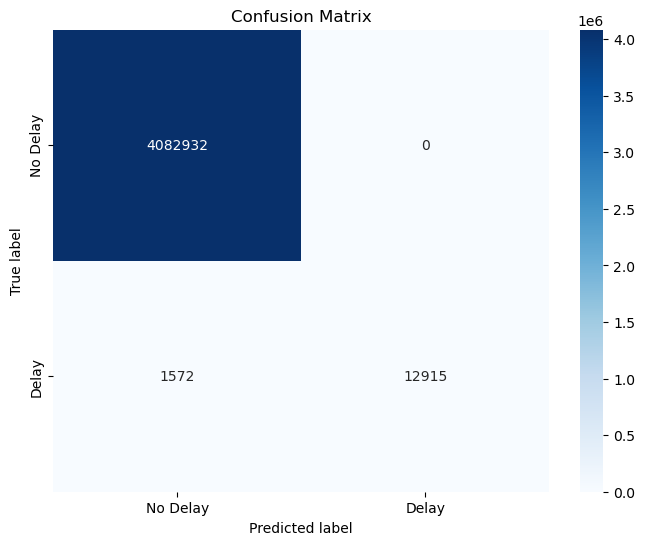

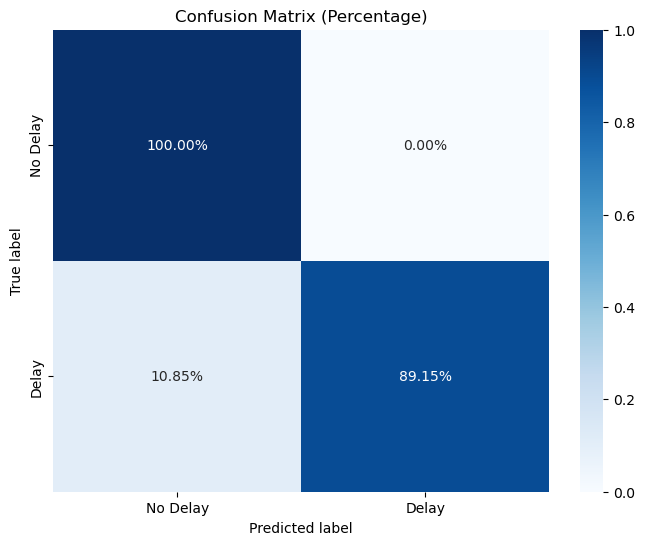

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import xgboost as xgb
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE


# Assume combined_df is your final DataFrame that includes both delay and synthetic no-delay records.
# Ensure that 'Datetime' is parsed as a datetime type.
combined_df['Datetime'] = pd.to_datetime(combined_df['Datetime'])

# ---------------------------
# Feature Engineering
# ---------------------------
# Extract useful time features from the Datetime column
combined_df['Hour'] = combined_df['Datetime'].dt.hour
combined_df['Minute'] = combined_df['Datetime'].dt.minute
combined_df['DayOfWeek'] = combined_df['Datetime'].dt.dayofweek  # Monday=0, Sunday=6

# We also have some categorical features. For example: Station Name, Line Number, Bound, and Cause for Delay.
# We'll use one-hot encoding to convert these into numeric features.
categorical_cols = ['Station Name', 'Line Number', 'Bound', 'Is Rush Hour', 'Is Terminal Station']
# Convert categorical variables into dummy/indicator variables.
data_encoded = pd.get_dummies(combined_df, columns=categorical_cols, drop_first=True)

# ---------------------------
# Define Features and Target
# ---------------------------
# Drop columns that are not needed for prediction.
# You might choose to drop raw datetime, or any other columns that don't add value.
X = data_encoded.drop(['Delayed', 'Datetime', "Cause for Delay", 'Min Delay', 'Min Gap', 'Day'], axis=1, errors='ignore')
y = data_encoded['Delayed']

# ---------------------------
# Split Data
# ---------------------------
# Use stratified splitting to preserve the balance of classes in train/test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=42)

# Undersampling overwhelming majority class (0) to balance the dataset
# This is a simple approach; you can also consider SMOTE or other techniques for more complex datasets.
rus = RandomUnderSampler(sampling_strategy=0.1, random_state=42)
X_train_res1, y_train_res1 = rus.fit_resample(X_train, y_train)

print("Training set class distribution after undersampling:")
print(pd.Series(y_train_res1).value_counts())

# SMOTE
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_res1, y_train_res1)

print("Training set class distribution after SMOTE:")
print(pd.Series(y_train_res).value_counts())


# ---------------------------
# Train XGBoost Model
# ---------------------------
# Initialize the XGBoost classifier. We disable the use of the label encoder for a warning-free run.
# Calculate the scale_pos_weight as the ratio of negative to positive examples
negatives = (y_train == 0).sum()
positives = (y_train == 1).sum()
scale_pos_weight = negatives / positives

# Initialize the XGBoost classifier with the adjusted scale_pos_weight
model = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    # scale_pos_weight=scale_pos_weight  # Adjust for class imbalance
)

model.fit(X_train_res, y_train_res)
model.fit(X_train, y_train)

# ---------------------------
# Model Evaluation
# ---------------------------
# Predict on the test set.
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate accuracy, ROC AUC, and generate a classification report.
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
report = classification_report(y_test, y_pred)

# Generate a confusion matrix

print("Accuracy:", accuracy)
print("ROC AUC:", roc_auc)
print("Classification Report:\n", report)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Delay', 'Delay'], yticklabels=['No Delay', 'Delay'])
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix')
plt.show()


# Confusion matrix based on percentage of records
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_percentage, annot=True, fmt='.2%', cmap='Blues', xticklabels=['No Delay', 'Delay'], yticklabels=['No Delay', 'Delay'])
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix (Percentage)')
plt.show()



### Try XGBoost for Regressor

In [ ]:
import pandas as pd
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
import xgboost as xgb

df = pd.read_csv('../data/cleaned_data_with_bounds.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df['Delayed'] = 1  # Mark original records as delayed
# Drop the Vehicle ID column
# original_df = original_df.drop(columns=['Vehicle'])
start_date = datetime(2022, 1, 1)
end_date = datetime(2024, 12, 31)
original_index = 0

# Make original df the original data frame starting datetime = 2022-01-01 00:00:00
original_df = df[(df['Datetime'] >= start_date) & (df['Datetime'] < end_date)].copy()

original_df['Hour'] = original_df['Datetime'].dt.hour
original_df['Minute'] = original_df['Datetime'].dt.minute
original_df['DayOfWeek'] = original_df['Datetime'].dt.dayofweek  # Monday=0, Sunday=6

original_df.head()

Mean Squared Error (MSE): 133.11153936080856
Mean Absolute Error (MAE): 4.3006441074597
R2 Score: 0.0051822662353515625


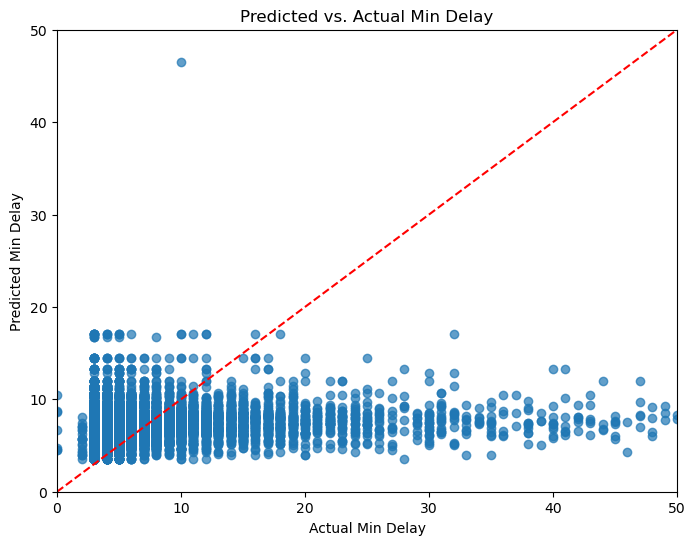

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# We'll drop Min Gap, and also drop columns that aren't useful for regression (e.g., raw Datetime and Day)
data = original_df.copy()
data = data.drop(columns=["Min Gap", "Datetime", "Day", "Cause for Delay"])

# Our target variable is "Min Delay"
target = "Min Delay"

# Identify categorical columns that we want to one-hot encode
categorical_cols = ["Station Name", "Line Number", "Bound"]

# One-hot encode categorical features
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

# Define features X and target y
X = data_encoded.drop(columns=[target])
y = data_encoded[target]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

# Initialize the XGBoost regressor
model_reg = xgb.XGBRegressor(random_state=42)

# Train the model
model_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model_reg.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R2 Score:", r2)

# Optional: Plot Actual vs. Predicted Min Delay values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Min Delay")
plt.ylabel("Predicted Min Delay")
plt.title("Predicted vs. Actual Min Delay")
plt.ylim([y_test.min(), 50])
plt.xlim([y_test.min(), 50])
# Draw a reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


Linear Regression Performance:
  MSE: 98.83488919807922
  MAE: 3.540891471836988
  R2: 0.2613510241294682

SVR Performance:
  MSE: 102.02454484794124
  MAE: 3.109311354906372
  R2: 0.2375129250708614


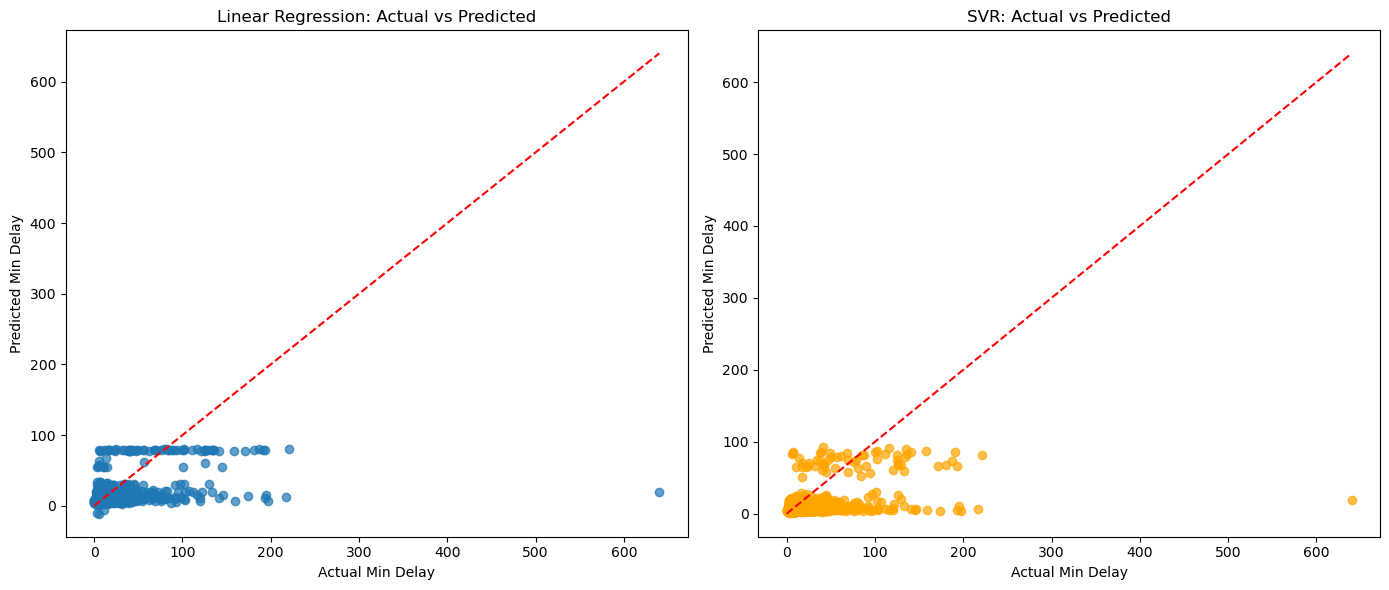

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
import matplotlib.pyplot as plt

# Assume df is your DataFrame with columns:
# Datetime, Day, Station Name, Line Number, Min Delay, Min Gap, Bound, 
# Cause for Delay, Is Rush Hour, Is Terminal Station, Delayed, Hour, Minute, DayOfWeek

# For regression, we want to predict "Min Delay". We'll drop "Min Gap" and non-useful columns like "Datetime" and "Day"
data = original_df.copy()
data = data.drop(columns=["Min Gap", "Datetime", "Day"])

# Set target variable
target = "Min Delay"

# Identify categorical features that need encoding.
categorical_cols = ["Station Name", "Line Number", "Bound", "Cause for Delay"]

# One-hot encode categorical features. Adjust drop_first if needed.
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

# Define features X and target y
X = data_encoded.drop(columns=[target])
y = data_encoded[target]

# Split data into training and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

### Linear Regression Model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

# Evaluate Linear Regression
mse_lin = mean_squared_error(y_test, y_pred_lin)
mae_lin = mean_absolute_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print("Linear Regression Performance:")
print("  MSE:", mse_lin)
print("  MAE:", mae_lin)
print("  R2:", r2_lin)

### Support Vector Regression (SVR) Model
# SVR may benefit from feature scaling. Here, for simplicity, we train without scaling;
# however, in practice you might want to scale your features.
svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

# Evaluate SVR
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("\nSVR Performance:")
print("  MSE:", mse_svr)
print("  MAE:", mae_svr)
print("  R2:", r2_svr)

plt.figure(figsize=(14, 6))

# Linear Regression Plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lin, alpha=0.7)
plt.xlabel("Actual Min Delay")
plt.ylabel("Predicted Min Delay")
plt.title("Linear Regression: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

# SVR Plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_svr, alpha=0.7, color='orange')
plt.xlabel("Actual Min Delay")
plt.ylabel("Predicted Min Delay")
plt.title("SVR: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.tight_layout()
plt.show()
